# Part 3: Exploratory Data Analysis (EDA) - Real Estate Price Analysis
This notebook explores patterns, distributions, correlations, and relationships within the cleaned real estate dataset using `pandas`, `matplotlib`, and `seaborn`.

## 1. Import Libraries and Load Cleaned Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting aesthetics
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Robust path resolver to locate cleaned_data.csv
possible_paths = [
    '../data/cleaned_data.csv',
    'data/cleaned_data.csv',
    os.path.abspath(os.path.join(os.getcwd(), 'data', 'cleaned_data.csv')),
    os.path.abspath(os.path.join(os.getcwd(), '..', 'data', 'cleaned_data.csv'))
]

csv_path = None
for p in possible_paths:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError('Could not locate cleaned_data.csv in any expected path.')

print(f'Loading data from: {csv_path}')
df = pd.read_csv(csv_path, engine='python')
print('Cleaned dataset loaded successfully.')
print(f'Shape: {df.shape}')

Loading data from: ../data/cleaned_data.csv


Cleaned dataset loaded successfully.
Shape: (51358, 11)


## 2. Summary Statistics

In [2]:
print('Summary Statistics of Numerical Columns:')
df.describe()

Summary Statistics of Numerical Columns:


,bhk,area,price,price_in_lakhs,price_per_sqft
count,51358.000000,51358.000000,51358.000000,51358.000000,51358.000000
mean,1.813875,878.404494,33.176428,121.211732,13480.816010
std,0.744365,337.231318,33.700989,87.838663,7105.590245
min,1.000000,136.000000,1.000000,4.490000,646.766169
25%,1.000000,630.000000,1.740000,59.952500,8000.000000
50%,2.000000,806.000000,24.800000,95.000000,11614.143921
75%,2.000000,1080.000000,63.000000,160.000000,18275.862069
max,5.000000,1907.000000,99.990000,650.000000,35268.505080


## 3. Distribution of Property Prices (`price_in_lakhs`)

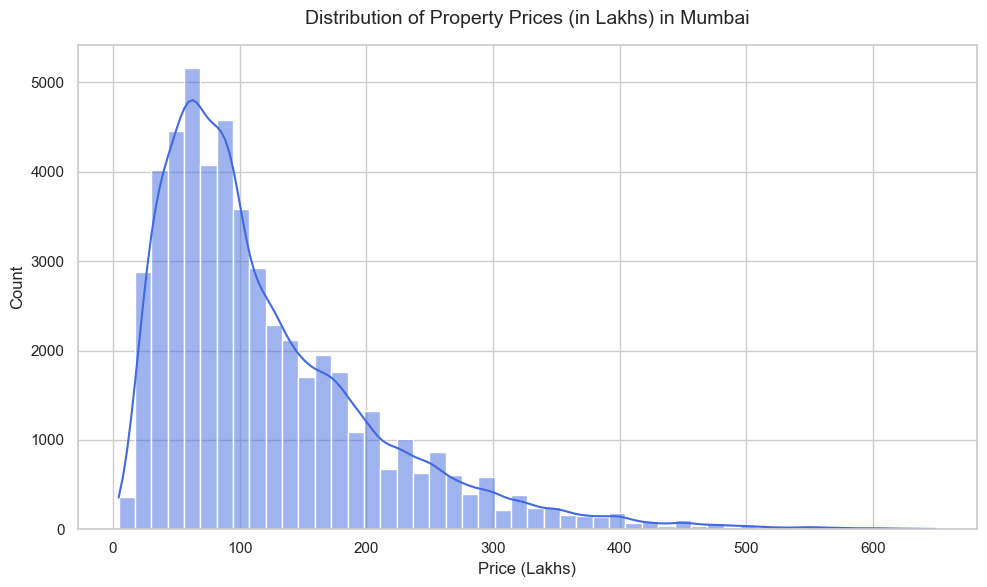

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price_in_lakhs'], kde=True, bins=50, color='royalblue')
plt.title('Distribution of Property Prices (in Lakhs) in Mumbai', fontsize=14, pad=15)
plt.xlabel('Price (Lakhs)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Price per Sqft Grouped by Region (Top 10 Regions)

C:\Users\srijan sahu\AppData\Local\Temp\ipykernel_12064\2037550185.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10, x='region', y='price_per_sqft', palette='Set2')


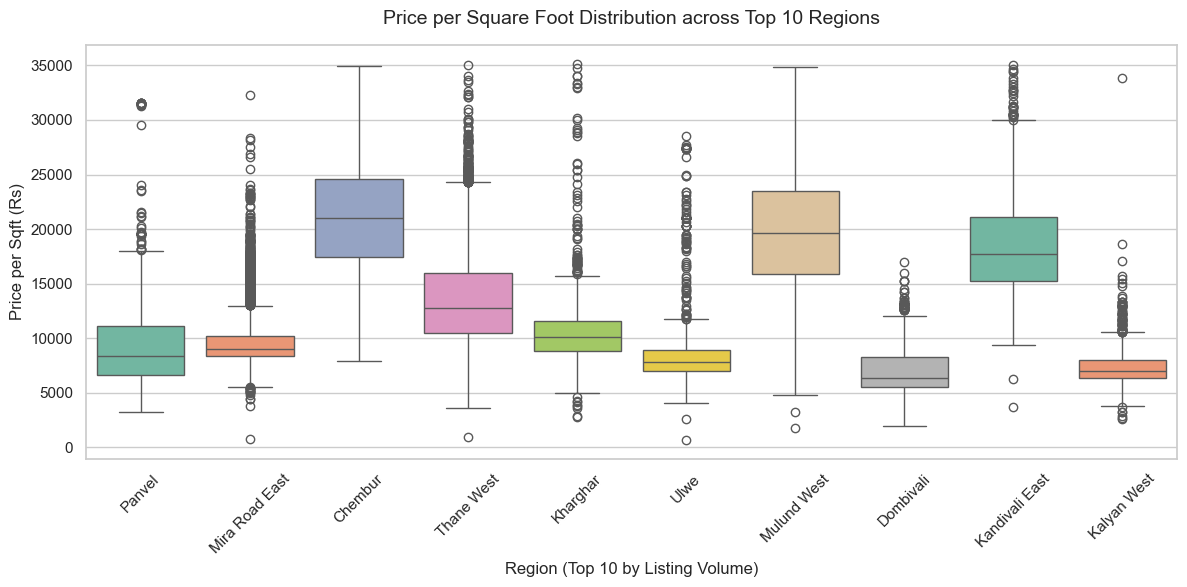

In [4]:
# Identify top 10 regions by listing count
top_10_regions = df['region'].value_counts().head(10).index.tolist()
df_top10 = df[df['region'].isin(top_10_regions)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top10, x='region', y='price_per_sqft', palette='Set2')
plt.title('Price per Square Foot Distribution across Top 10 Regions', fontsize=14, pad=15)
plt.xlabel('Region (Top 10 by Listing Volume)', fontsize=12)
plt.ylabel('Price per Sqft (Rs)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Average Price by BHK Configuration

C:\Users\srijan sahu\AppData\Local\Temp\ipykernel_12064\3810765905.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='bhk', y='price_in_lakhs', estimator='mean', errorbar=None, palette='Blues_d')


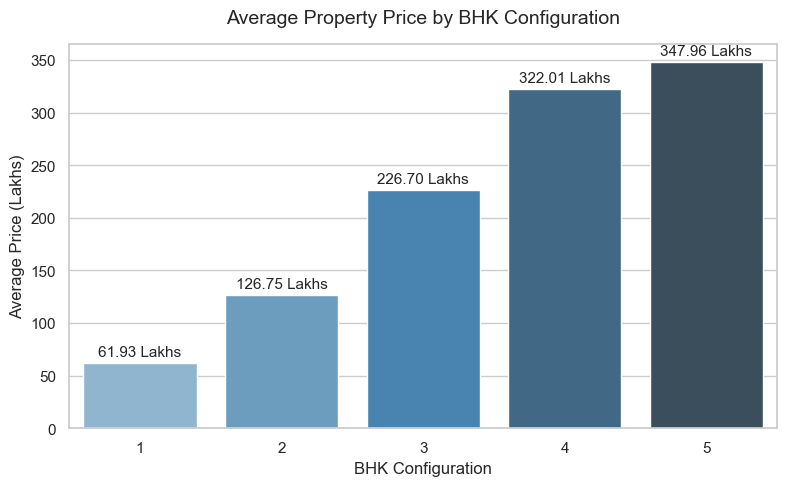

In [5]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='bhk', y='price_in_lakhs', estimator='mean', errorbar=None, palette='Blues_d')
plt.title('Average Property Price by BHK Configuration', fontsize=14, pad=15)
plt.xlabel('BHK Configuration', fontsize=12)
plt.ylabel('Average Price (Lakhs)', fontsize=12)
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f Lakhs', padding=3)
plt.tight_layout()
plt.show()

## 6. Property Area vs Price (Colored by BHK)

Pearson Correlation Coefficient: 0.6552


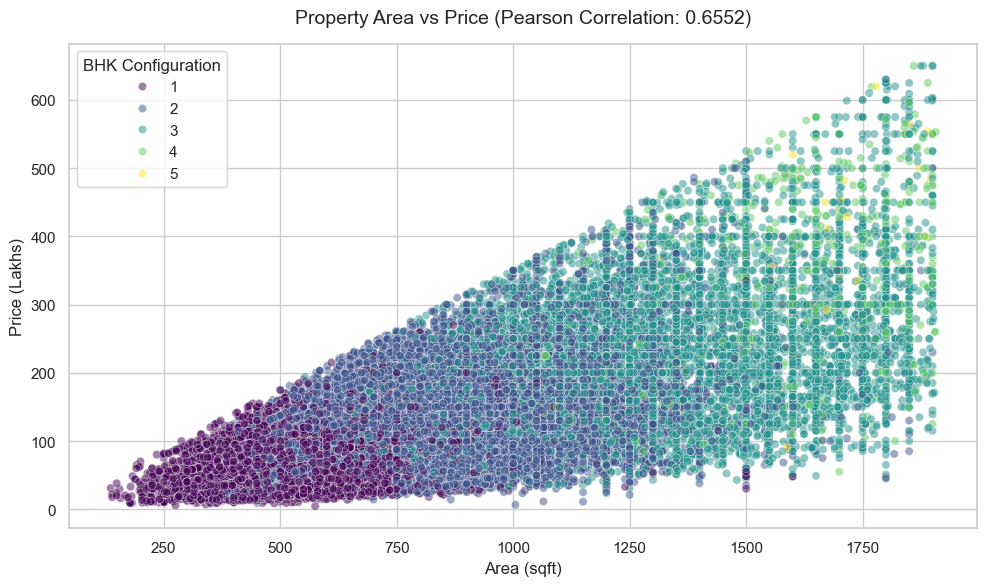

In [6]:
correlation_coef = df['area'].corr(df['price_in_lakhs'])
print(f'Pearson Correlation Coefficient: {correlation_coef:.4f}')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='area', y='price_in_lakhs', hue='bhk', palette='viridis', alpha=0.5)
plt.title(f'Property Area vs Price (Pearson Correlation: {correlation_coef:.4f})', fontsize=14, pad=15)
plt.xlabel('Area (sqft)', fontsize=12)
plt.ylabel('Price (Lakhs)', fontsize=12)
plt.legend(title='BHK Configuration')
plt.tight_layout()
plt.show()

## 7. Average Price per Sqft by Property Type

C:\Users\srijan sahu\AppData\Local\Temp\ipykernel_12064\2508332082.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='type', y='price_per_sqft', estimator='mean', errorbar=None, palette='coolwarm')


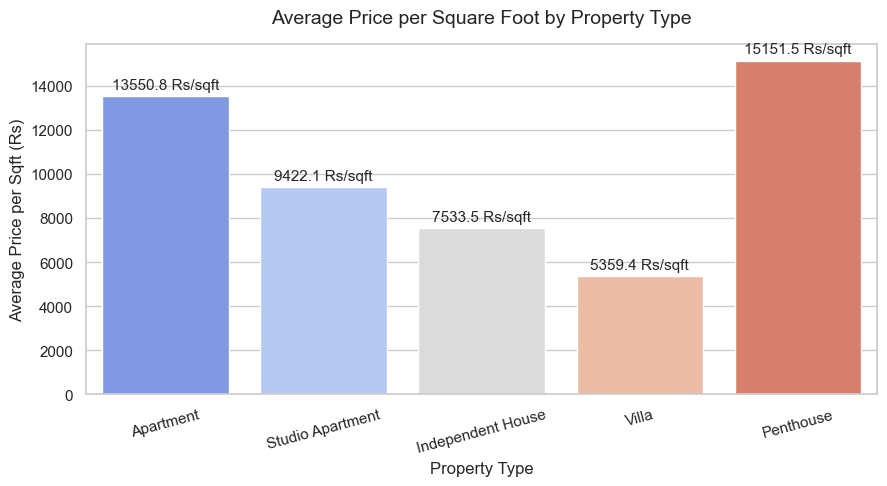

In [7]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='type', y='price_per_sqft', estimator='mean', errorbar=None, palette='coolwarm')
plt.title('Average Price per Square Foot by Property Type', fontsize=14, pad=15)
plt.xlabel('Property Type', fontsize=12)
plt.ylabel('Average Price per Sqft (Rs)', fontsize=12)
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.1f Rs/sqft', padding=3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 8. Listing Status Distribution in Top 10 Regions

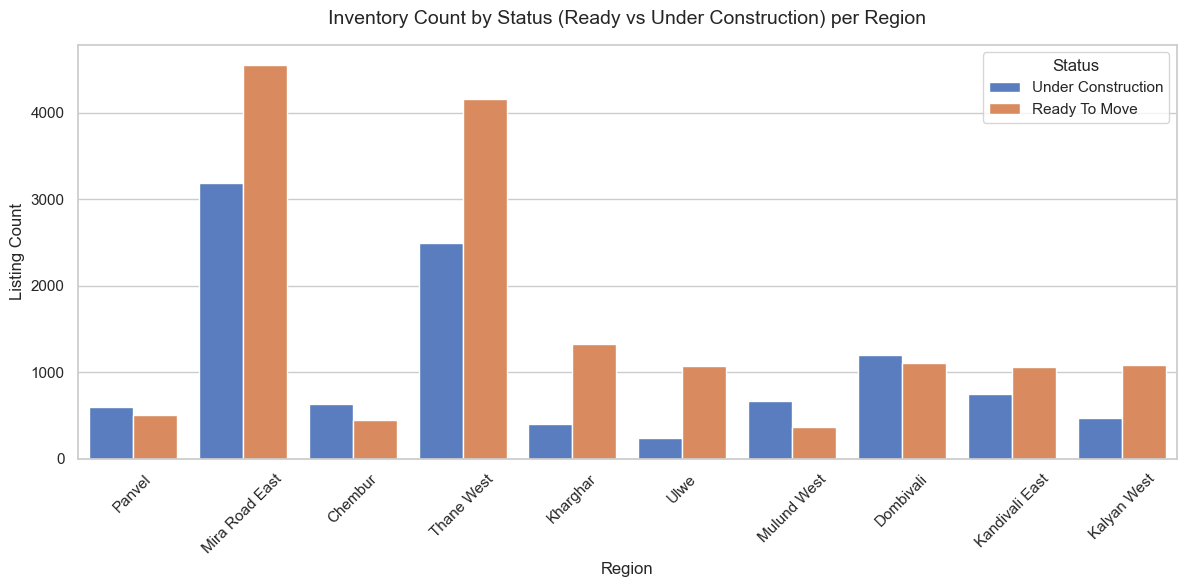

In [8]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_top10, x='region', hue='status', palette='muted')
plt.title('Inventory Count by Status (Ready vs Under Construction) per Region', fontsize=14, pad=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Listing Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

## Written Insights & Analysis Patterns

Based on the visualization outputs and statistical calculations, here are the core findings:

1. **Geographic Concentration of Inventory**:
   The real estate supply is highly concentrated. **Mira Road East** (7,742 listings) and **Thane West** (6,648 listings) dominate listing count, accounting for approximately **28%** of total property records. This suggests these two regions are the primary transaction hubs for middle-income residential real estate in the Mumbai Metropolitan Region (MMR).

2. **BHK Premium & Price Progression**:
   Property prices scale aggressively with BHK configurations. A **1 BHK** apartment averages **61.93 Lakhs**, which more than doubles to **126.75 Lakhs** for a **2 BHK** (+104.7%). A **3 BHK** represents another major tier shift, averaging **226.70 Lakhs** (+78.9% increase relative to 2 BHK), while 4 BHK and 5 BHK units show average valuations exceeding 320 Lakhs. This steep slope reflects the premium placed on space in high-density urban areas.

3. **Relationship Between Size and Total Price**:
   There is a strong positive correlation between property area (sqft) and price (Lakhs), with a **Pearson Correlation Coefficient of 0.6552**.
   The scatter plot confirms that as area increases, price climbs, but price variance also widens significantly for larger configurations, indicating that luxury elements and specific micro-localities heavily skew prices of larger properties.

4. **Typology Premium (Price per Sqft)**:
   Different property typologies have vastly different valuation structures. **Penthouses** command the highest average price per square foot at **15,151.52 Rs/sqft**, followed closely by **Apartments** at **13,550.79 Rs/sqft**. Conversely, **Villas** are listed at the lowest average price per sqft at **5,359.39 Rs/sqft**. This indicates that dense high-rise structures (apartments/penthouses) command a premium rate per unit area, whereas low-density horizontal properties (villas) have a much lower unit rate, likely situated in far suburban or residential enclaves.

5. **Inventory Readiness Across Regions**:
   Analysing ready-to-move (RTM) vs under-construction (UC) properties in the top 10 regions reveals development maturity:
   - Mature hubs like **Thane West** (4,152 RTM vs 2,496 UC) and **Mira Road East** (4,554 RTM vs 3,188 UC) have high volumes of finished, immediate-occupancy inventory.
   - Emerging premium zones like **Mulund West** (370 RTM vs 670 UC) and **Chembur** (454 RTM vs 634 UC) are heavily tilted towards under-construction inventory, indicating substantial new development projects currently underway.